<a href="https://colab.research.google.com/github/LizethMesaC/TrabajoFinalCDD/blob/main/Trabajo_Final_CDD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="font-family: Arial;">
<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">
<h3 style="text-align: center;">
<b>ESPECIALIZACIÓN EN CIENCIA DE DATOS E INGELIGENCIA ARTIFICIAL</b>
</h3>
<h3 style="text-align: center; color:  #C2262B;"> <!--Color institucional-->
<strong>Módulo Introducción a la Ciencia de Datos<strong>
</h3>
<h3>
<b>Trabajo Final:</b> <u>Estimación de niveles de obesidad basada en hábitos alimenticios y condición física</u>
</h3>
<hr style="width:100%; border:1px solid withe;">
<h6 style="text-align: rigth; margin-bottom: 5px">
<b> Integrantes:</b>
<ul>
    <li>Yuly Del Carmen Mosquera Martinez</li>
    <li>Yeny Liliana Guzman Urrego</li>
    <li>Angie Carolina Piedrahita Cañaveral</li>
    <li>Lizeth Mesa Cadavid</li>
</ul>
</h3


---

##**Detalles Dataset**
El conjunto de datos seleccionado está diseñado para estimar los niveles de obesidad en personas de México, Perú y Colombia, a partir de sus hábitos alimenticios y condición física.

 Contiene 2111 registros y 17 variables que describen características como estilo de vida, alimentación y actividad física. La variable objetivo, denominada NObesity, clasifica a los individuos en siete categorías:
- Peso insuficiente  
- Peso normal  
- Sobrepeso nivel I  
- Sobrepeso nivel II  
- Obesidad tipo I  
- Obesidad tipo II  
- Obesidad tipo III

Es importante destacar que el 77% de los datos fue generado de forma sintética mediante técnicas como SMOTE, mientras que el 23% proviene de datos reales recolectados a través de una plataforma web.

##**Objetivo General**
Analizar los factores relacionados con los hábitos de vida, alimentación y actividad física que influyen en el nivel de obesidad de los individuos, mediante un Análisis Exploratorio de Datos (EDA), con el fin de identificar patrones relevantes y posibles relaciones entre variables.

##**Objetivos especificos**
1. Determinar qué variables están más relacionadas con el nivel de obesidad (NObeyesdad).
2. Analizar si el consumo de alimentos altos en calorías (FAVC) influye en el nivel de obesidad.
3. Evaluar la relación entre la frecuencia de comidas entre horas (CAEC) y el nivel de obesidad.
4. Examinar la relación entre la actividad física (FAF) y el nivel de obesidad.
5. Analizar si el uso de tecnología (TUE) está asociado con el nivel de obesidad.
6. Identificar si el medio de transporte utilizado (MTRANS) influye en el nivel de obesidad.
7. Determinar si los antecedentes familiares de obesidad influyen en el nivel actual de obesidad.
8. Analizar si existen relación en el nivel de obesidad y el género.



#**Variables del conjunto de datos:**
| N° | NOMBRE DE LA VARIABLE | DESCRIPCIÓN | TIPO DE DATO |
|:--:|:----------------------|:-------------|:-------------:|
| 1 | Gender | Género del individuo | Categórico |
| 2 | Age | Edad de la persona | Continuo |
| 3 | Height | Estatura | Continuo |
| 4 | Weight | Peso | Continuo |
| 5 | family_history_with_overweight | Antecedentes familiares de sobrepeso | Binario |
| 6 | FAVC | Consumo frecuente de alimentos altos en calorías | Binario |
| 7 | FCVC | Frecuencia de consumo de verduras | Entero |
| 8 | NCP | Número de comidas principales al día | Continuo |
| 9 | CAEC | Consumo de alimentos entre comidas | Categórico |
| 10 | SMOKE | Si la persona fuma o no | Binario |
| 11 | CH2O | Consumo de agua diario | Continuo |
| 12 | SCC | Control de calorías consumidas | Binario |
| 13 | FAF | Actividad física semanal | Continuo |
| 14 | TUE | Tiempo usando dispositivos tecnológicos | Entero |
| 15 | CALC | Consumo de alcohol | Categórico |
| 16 | MTRANS | Medio de transporte utilizado | Categórico |
| 17 | NObeyesdad | Nivel de obesidad (variable objetivo) | Categórico |


In [1]:
"""Importamos librerías"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 52
rng = np.random.default_rng(RANDOM_STATE)

In [2]:
from google.colab import files #ESTO TOCA CAMBIARLO
uploaded = files.upload()

Saving Untitled5.ipynb to Untitled5.ipynb


In [3]:
"""Cargamos los datos"""

#url = "ObesityDataSet_raw_and_data_sinthetic.csv"

df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000,1.620,64.000,yes,no,2.000,3.000,Sometimes,no,2.000,no,0.000,1.000,no,Public_Transportation,Normal_Weight
1,Female,21.000,1.520,56.000,yes,no,3.000,3.000,Sometimes,yes,3.000,yes,3.000,0.000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000,1.800,77.000,yes,no,2.000,3.000,Sometimes,no,2.000,no,2.000,1.000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000,1.800,87.000,no,no,3.000,3.000,Sometimes,no,2.000,no,2.000,0.000,Frequently,Walking,Overweight_Level_I
4,Male,22.000,1.780,89.800,no,no,2.000,1.000,Sometimes,no,2.000,no,0.000,0.000,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print("\nTipos de datos:")
display(df.dtypes.to_frame("dtype"))

Filas: 2111
Columnas: 17

Tipos de datos:


,dtype
Gender,object
Age,float64
Height,float64
Weight,float64
family_history_with_overweight,object
FAVC,object
FCVC,float64
NCP,float64
CAEC,object
SMOKE,object


In [5]:
print("\nPrimeras filas:")
display(df.head())


Primeras filas:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000,1.620,64.000,yes,no,2.000,3.000,Sometimes,no,2.000,no,0.000,1.000,no,Public_Transportation,Normal_Weight
1,Female,21.000,1.520,56.000,yes,no,3.000,3.000,Sometimes,yes,3.000,yes,3.000,0.000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000,1.800,77.000,yes,no,2.000,3.000,Sometimes,no,2.000,no,2.000,1.000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000,1.800,87.000,no,no,3.000,3.000,Sometimes,no,2.000,no,2.000,0.000,Frequently,Walking,Overweight_Level_I
4,Male,22.000,1.780,89.800,no,no,2.000,1.000,Sometimes,no,2.000,no,0.000,0.000,Sometimes,Public_Transportation,Overweight_Level_II


In [6]:
print("\nMuestra aleatoria de registros:")
display(df.sample(5))


Muestra aleatoria de registros:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
863,Female,30.614,1.646,69.169,yes,yes,2.000,3.000,Sometimes,no,1.131,no,0.061,0.000,Sometimes,Automobile,Overweight_Level_I
652,Female,21.288,1.556,42.360,no,no,2.318,1.082,Frequently,no,1.220,no,0.033,0.000,no,Public_Transportation,Insufficient_Weight
738,Female,19.946,1.603,45.000,no,no,3.000,3.000,Frequently,no,2.488,yes,1.230,0.000,Sometimes,Public_Transportation,Insufficient_Weight
860,Male,20.000,1.817,85.000,yes,yes,2.951,3.000,Sometimes,no,3.000,no,2.434,0.562,Sometimes,Public_Transportation,Overweight_Level_I
1713,Male,27.394,1.764,112.323,yes,yes,1.925,3.000,Sometimes,no,2.007,no,0.177,0.512,Sometimes,Automobile,Obesity_Type_II


In [7]:
"""Revisar titulo de columnas"""
print("\nNombres de variables:")
print(df.columns)


Nombres de variables:
Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')


In [8]:
"""Cambiamos el titulo de algunas columnas para entenderlo mejor"""
# Titulo Actual --------> Nuevo titulo
# Gender-----------------------------Gender
# Age--------------------------------Age
# Height-----------------------------Height
# Weight-----------------------------Weight
# Family_history_with_overweight-----Family_history_overweight
# FAVC-------------------------------Frequent_high_caloric_food
# FCVC-------------------------------Frequent_consumption_vegetables
# NCP--------------------------------Number_of_main_meals
# CAEC-------------------------------Food_between_meals
# Smoke------------------------------Smoke
# CH2O-------------------------------Daily_Water_Intake
# SCC--------------------------------Calorie_Monitoring
# FAF--------------------------------Physical_Activity_Frequency
# TUE--------------------------------Technology_Use_Time
# CALC-------------------------------Alcohol_Consumption
# MTRANS-----------------------------Transportation_type
# NObeyesdad-------------------------Obesity_Level

new_columns = [
    "Gender",
    "Age",
    "Height",
    "Weight",
    "Family_history_overweight",
    "Frequent_high_caloric_food",
    "Frequent_consumption_vegetables",
    "Number_of_main_meals",
    "Food_between_meals",
    "Smoke",
    "Daily_Water_Intake",
    "Calorie_Monitoring",
    "Physical_Activity_Frequency",
    "Technology_Use_Time",
    "Alcohol_Consumption",
    "Transportation_type",
    "Obesity_Level"
]

df.columns = new_columns
df.head()

,Gender,Age,Height,Weight,Family_history_overweight,Frequent_high_caloric_food,Frequent_consumption_vegetables,Number_of_main_meals,Food_between_meals,Smoke,Daily_Water_Intake,Calorie_Monitoring,Physical_Activity_Frequency,Technology_Use_Time,Alcohol_Consumption,Transportation_type,Obesity_Level
0,Female,21.000,1.620,64.000,yes,no,2.000,3.000,Sometimes,no,2.000,no,0.000,1.000,no,Public_Transportation,Normal_Weight
1,Female,21.000,1.520,56.000,yes,no,3.000,3.000,Sometimes,yes,3.000,yes,3.000,0.000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000,1.800,77.000,yes,no,2.000,3.000,Sometimes,no,2.000,no,2.000,1.000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000,1.800,87.000,no,no,3.000,3.000,Sometimes,no,2.000,no,2.000,0.000,Frequently,Walking,Overweight_Level_I
4,Male,22.000,1.780,89.800,no,no,2.000,1.000,Sometimes,no,2.000,no,0.000,0.000,Sometimes,Public_Transportation,Overweight_Level_II


In [9]:
print("\nInformación de los datos")
df.info()


Información de los datos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Gender                           2111 non-null   object 
 1   Age                              2111 non-null   float64
 2   Height                           2111 non-null   float64
 3   Weight                           2111 non-null   float64
 4   Family_history_overweight        2111 non-null   object 
 5   Frequent_high_caloric_food       2111 non-null   object 
 6   Frequent_consumption_vegetables  2111 non-null   float64
 7   Number_of_main_meals             2111 non-null   float64
 8   Food_between_meals               2111 non-null   object 
 9   Smoke                            2111 non-null   object 
 10  Daily_Water_Intake               2111 non-null   float64
 11  Calorie_Monitoring               2111 non-null   object 

In [10]:
print("\nEstadísticas descriptivas:")
display(df.describe(include="all").T)


Estadísticas descriptivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,2111,2,Male,1068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,"2,111.000",NaN,NaN,NaN,24.313,6.346,14.000,19.947,22.778,26.000,61.000
Height,"2,111.000",NaN,NaN,NaN,1.702,0.093,1.450,1.630,1.700,1.768,1.980
Weight,"2,111.000",NaN,NaN,NaN,86.586,26.191,39.000,65.473,83.000,107.431,173.000
Family_history_overweight,2111,2,yes,1726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Frequent_high_caloric_food,2111,2,yes,1866,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Frequent_consumption_vegetables,"2,111.000",NaN,NaN,NaN,2.419,0.534,1.000,2.000,2.386,3.000,3.000
Number_of_main_meals,"2,111.000",NaN,NaN,NaN,2.686,0.778,1.000,2.659,3.000,3.000,4.000
Food_between_meals,2111,4,Sometimes,1765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Smoke,2111,2,no,2067,NaN,NaN,NaN,NaN,NaN,NaN,NaN


CALIDAD DE LOS DATOS

In [11]:
#CALIDAD DE LOS DATOS
missing = (
    df.isna()
      .sum()
      .to_frame("n_missing")
      .assign(pct_missing=lambda x: 100 * x["n_missing"] / len(df))
      .sort_values("pct_missing", ascending=False)
)

duplicates = df.duplicated().sum()

display(missing)
print(f"Registros duplicados: {duplicates}")

,n_missing,pct_missing
Gender,0,0.000
Age,0,0.000
Height,0,0.000
Weight,0,0.000
Family_history_overweight,0,0.000
Frequent_high_caloric_food,0,0.000
Frequent_consumption_vegetables,0,0.000
Number_of_main_meals,0,0.000
Food_between_meals,0,0.000
Smoke,0,0.000


Registros duplicados: 24


In [12]:
"""Como se identificaron registros duplicados, debo visualizarlos"""
df[df.duplicated()]

,Gender,Age,Height,Weight,Family_history_overweight,Frequent_high_caloric_food,Frequent_consumption_vegetables,Number_of_main_meals,Food_between_meals,Smoke,Daily_Water_Intake,Calorie_Monitoring,Physical_Activity_Frequency,Technology_Use_Time,Alcohol_Consumption,Transportation_type,Obesity_Level
98,Female,21.000,1.520,42.000,no,no,3.000,1.000,Frequently,no,1.000,no,0.000,0.000,Sometimes,Public_Transportation,Insufficient_Weight
106,Female,25.000,1.570,55.000,no,yes,2.000,1.000,Sometimes,no,2.000,no,2.000,0.000,Sometimes,Public_Transportation,Normal_Weight
174,Male,21.000,1.620,70.000,no,yes,2.000,1.000,no,no,3.000,no,1.000,0.000,Sometimes,Public_Transportation,Overweight_Level_I
179,Male,21.000,1.620,70.000,no,yes,2.000,1.000,no,no,3.000,no,1.000,0.000,Sometimes,Public_Transportation,Overweight_Level_I
184,Male,21.000,1.620,70.000,no,yes,2.000,1.000,no,no,3.000,no,1.000,0.000,Sometimes,Public_Transportation,Overweight_Level_I
209,Female,22.000,1.690,65.000,yes,yes,2.000,3.000,Sometimes,no,2.000,no,1.000,1.000,Sometimes,Public_Transportation,Normal_Weight
309,Female,16.000,1.660,58.000,no,no,2.000,1.000,Sometimes,no,1.000,no,0.000,1.000,no,Walking,Normal_Weight
460,Female,18.000,1.620,55.000,yes,yes,2.000,3.000,Frequently,no,1.000,no,1.000,1.000,no,Public_Transportation,Normal_Weight
467,Male,22.000,1.740,75.000,yes,yes,3.000,3.000,Frequently,no,1.000,no,1.000,0.000,no,Automobile,Normal_Weight
496,Male,18.000,1.720,53.000,yes,yes,2.000,3.000,Sometimes,no,2.000,no,0.000,2.000,Sometimes,Public_Transportation,Insufficient_Weight


In [13]:
"""Se eliminan los valores duplicados"""
df = df.drop_duplicates().reset_index(drop=True)
print(df.duplicated().sum())

0


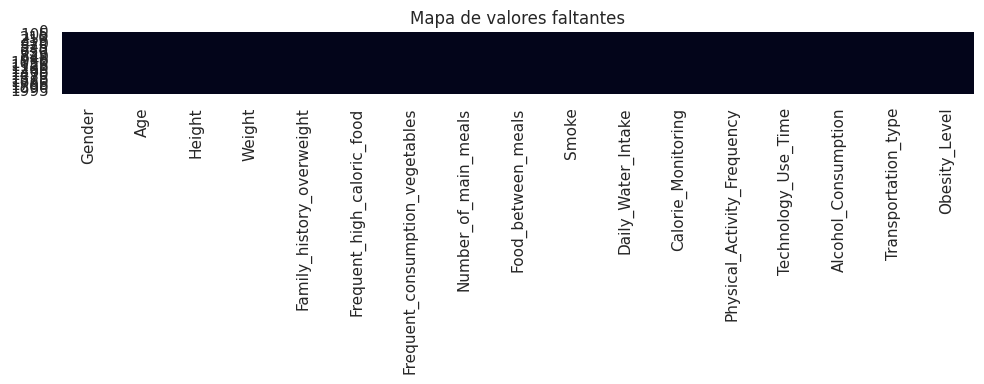

In [14]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Mapa de valores faltantes")
plt.tight_layout()
plt.show()

No se observan valores faltantes.

In [15]:
"""Observo las variables categoricas"""
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(f"\n {col}")
    display(df[col].value_counts())
    print("Valores únicos:", df[col].unique())


 Gender


,count
Gender,
Male,1052
Female,1035


Valores únicos: ['Female' 'Male']

 Family_history_overweight


,count
Family_history_overweight,
yes,1722
no,365


Valores únicos: ['yes' 'no']

 Frequent_high_caloric_food


...

Valores únicos: ['no' 'Sometimes' 'Frequently' 'Always']

 Transportation_type


,count
Transportation_type,
Public_Transportation,1558
Automobile,456
Walking,55
Motorbike,11
Bike,7


Valores únicos: ['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']

 Obesity_Level


,count
Obesity_Level,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_II,290
Normal_Weight,282
Overweight_Level_I,276
Insufficient_Weight,267


Valores únicos: ['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


In [16]:
"""Convertir variables categóricas (object) a binarias (int)"""

col_binarias = [
    "Family_history_overweight",
    "Frequent_high_caloric_food",
    "Smoke",
    "Calorie_Monitoring"
]

for col in col_binarias:
    df[col] = df[col].map({"no": 0, "yes": 1})

print("\n\n Variables Binarias luego de la conversión")
for col in col_binarias:
    print(f"\n{col}")
    print(df[col].value_counts())



 Variables Binarias luego de la conversión

Family_history_overweight
Family_history_overweight
1    1722
0     365
Name: count, dtype: int64

Frequent_high_caloric_food
Frequent_high_caloric_food
1    1844
0     243
Name: count, dtype: int64

Smoke
Smoke
0    2043
1      44
Name: count, dtype: int64

Calorie_Monitoring
Calorie_Monitoring
0    1991
1      96
Name: count, dtype: int64


In [17]:
"""Convertir variables categoricas (object) a  Ordinales (int)"""
escala_ordinal = {
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
}

variables_ordinales = [
    "Food_between_meals",
    "Alcohol_Consumption"
]

for col in variables_ordinales:
    df[col] = df[col].str.strip().map(escala_ordinal)

print(" Variables ordinales luego de la conversión:")

for col in variables_ordinales:
    print(f"\n{col}")
    print(df[col].value_counts())

 Variables ordinales luego de la conversión:

Food_between_meals
Food_between_meals
1    1761
2     236
3      53
0      37
Name: count, dtype: int64

Alcohol_Consumption
Alcohol_Consumption
1    1380
0     636
2      70
3       1
Name: count, dtype: int64


In [18]:
df.isna().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
Family_history_overweight,0
Frequent_high_caloric_food,0
Frequent_consumption_vegetables,0
Number_of_main_meals,0
Food_between_meals,0
Smoke,0


In [19]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2087 entries, 0 to 2086
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Gender                           2087 non-null   object 
 1   Age                              2087 non-null   float64
 2   Height                           2087 non-null   float64
 3   Weight                           2087 non-null   float64
 4   Family_history_overweight        2087 non-null   int64  
 5   Frequent_high_caloric_food       2087 non-null   int64  
 6   Frequent_consumption_vegetables  2087 non-null   float64
 7   Number_of_main_meals             2087 non-null   float64
 8   Food_between_meals               2087 non-null   int64  
 9   Smoke                            2087 non-null   int64  
 10  Daily_Water_Intake               2087 non-null   float64
 11  Calorie_Monitoring               2087 non-null   int64  
 12  Physical_Activity_Fr

,Gender,Age,Height,Weight,Family_history_overweight,Frequent_high_caloric_food,Frequent_consumption_vegetables,Number_of_main_meals,Food_between_meals,Smoke,Daily_Water_Intake,Calorie_Monitoring,Physical_Activity_Frequency,Technology_Use_Time,Alcohol_Consumption,Transportation_type,Obesity_Level
0,Female,21.000,1.620,64.000,1,0,2.000,3.000,1,0,2.000,0,0.000,1.000,0,Public_Transportation,Normal_Weight
1,Female,21.000,1.520,56.000,1,0,3.000,3.000,1,1,3.000,1,3.000,0.000,1,Public_Transportation,Normal_Weight
2,Male,23.000,1.800,77.000,1,0,2.000,3.000,1,0,2.000,0,2.000,1.000,2,Public_Transportation,Normal_Weight
3,Male,27.000,1.800,87.000,0,0,3.000,3.000,1,0,2.000,0,2.000,0.000,2,Walking,Overweight_Level_I
4,Male,22.000,1.780,89.800,0,0,2.000,1.000,1,0,2.000,0,0.000,0.000,1,Public_Transportation,Overweight_Level_II


In [21]:
"""Separo variables categoricas y numericas"""
num_cols = df.select_dtypes(include="number").columns
cat_cols = df.select_dtypes(include="object").columns

Analisis variables numericas

In [22]:
#Media, mediana, min y max variables númericas
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,"2,087.000",24.353,6.369,14.000,19.916,22.848,26.000,61.000
Height,"2,087.000",1.703,0.093,1.450,1.630,1.702,1.769,1.980
Weight,"2,087.000",86.859,26.191,39.000,66.000,83.101,108.016,173.000
Family_history_overweight,"2,087.000",0.825,0.380,0.000,1.000,1.000,1.000,1.000
Frequent_high_caloric_food,"2,087.000",0.884,0.321,0.000,1.000,1.000,1.000,1.000
Frequent_consumption_vegetables,"2,087.000",2.421,0.535,1.000,2.000,2.396,3.000,3.000
Number_of_main_meals,"2,087.000",2.701,0.765,1.000,2.697,3.000,3.000,4.000
Food_between_meals,"2,087.000",1.146,0.459,0.000,1.000,1.000,1.000,3.000
Smoke,"2,087.000",0.021,0.144,0.000,0.000,0.000,0.000,1.000
Daily_Water_Intake,"2,087.000",2.005,0.608,1.000,1.591,2.000,2.466,3.000


In [29]:
#Mediana
df[num_cols].median()

,0
Age,22.848
Height,1.702
Weight,83.101
Family_history_overweight,1.000
Frequent_high_caloric_food,1.000
Frequent_consumption_vegetables,2.396
Number_of_main_meals,3.000
Food_between_meals,1.000
Smoke,0.000
Daily_Water_Intake,2.000


In [30]:
#Asimetria
df[num_cols].skew()

,0
Age,1.514
Height,-0.025
Weight,0.242
Family_history_overweight,-1.713
Frequent_high_caloric_food,-2.393
Frequent_consumption_vegetables,-0.448
Number_of_main_meals,-1.138
Food_between_meals,2.094
Smoke,6.672
Daily_Water_Intake,-0.106


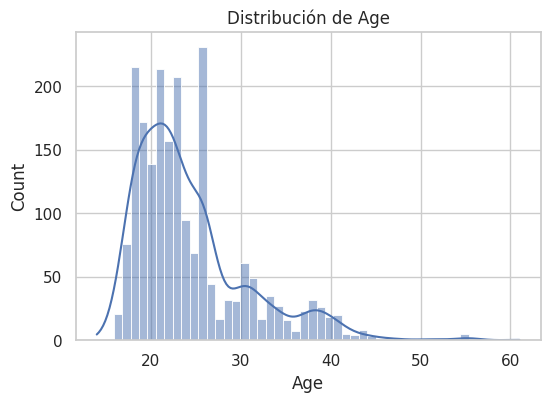

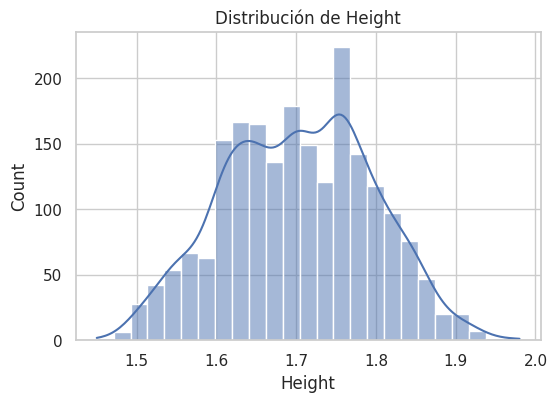

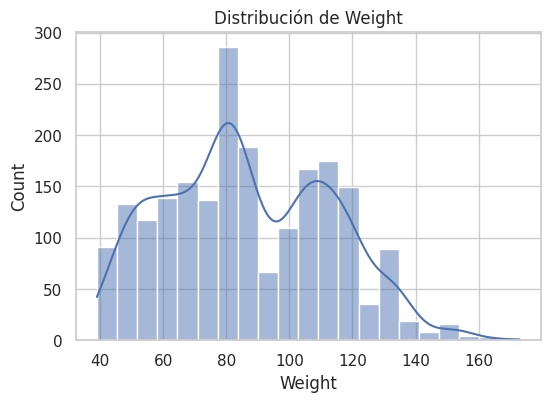

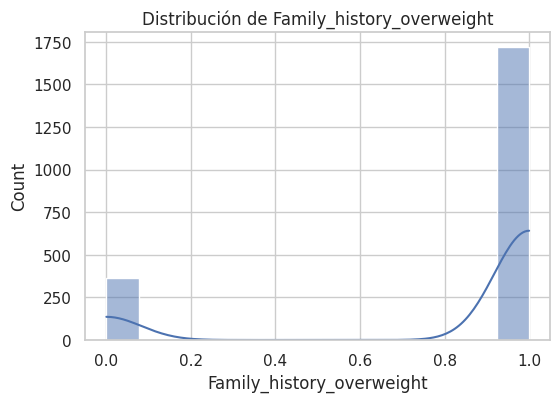

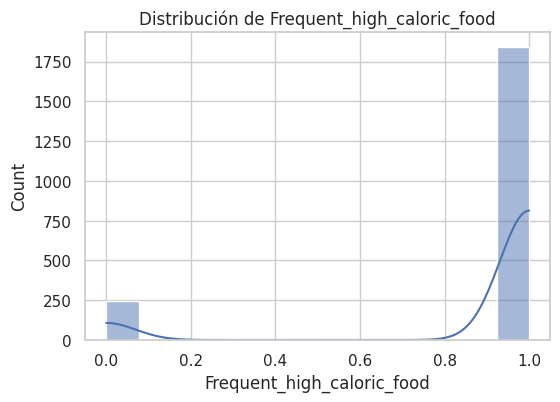

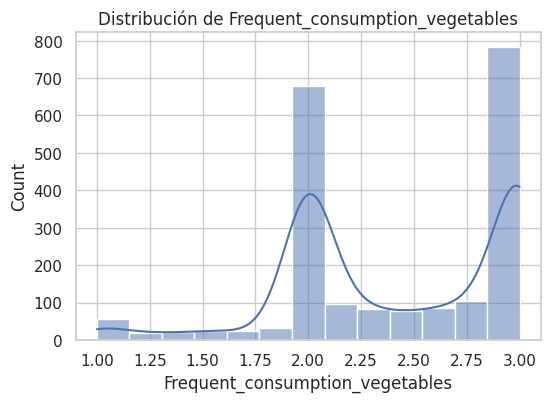

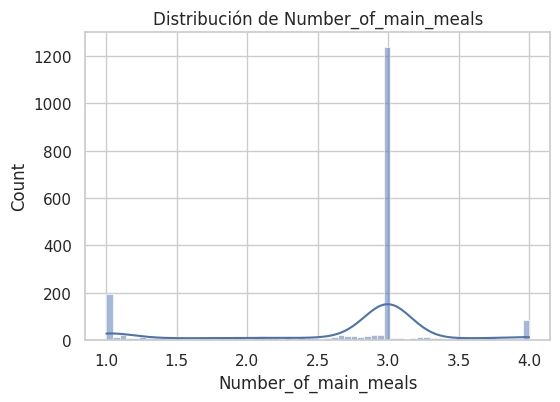

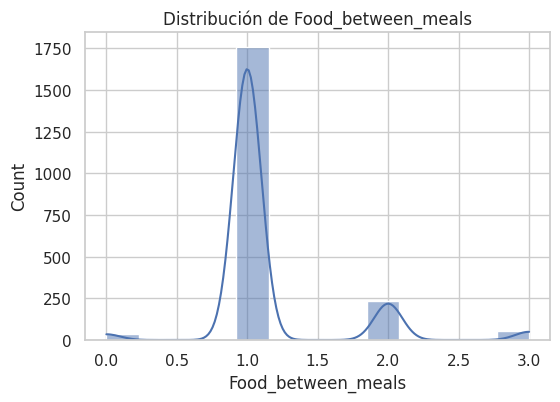

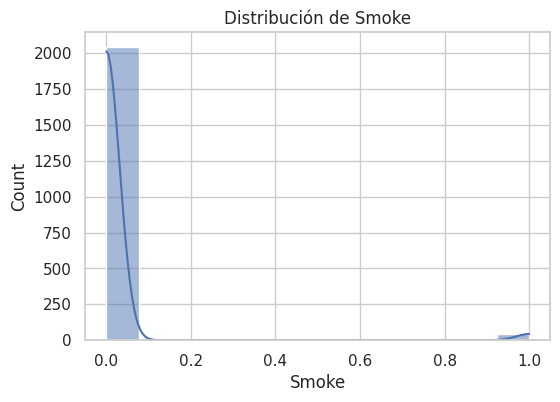

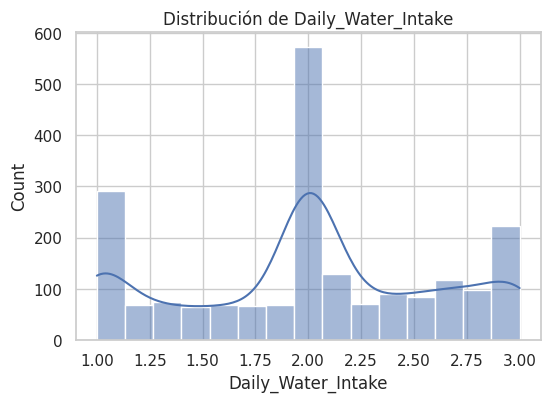

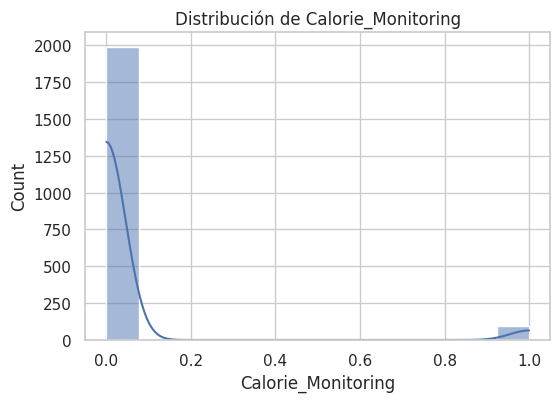

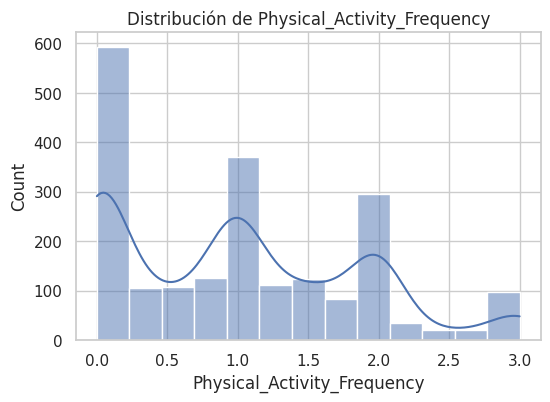

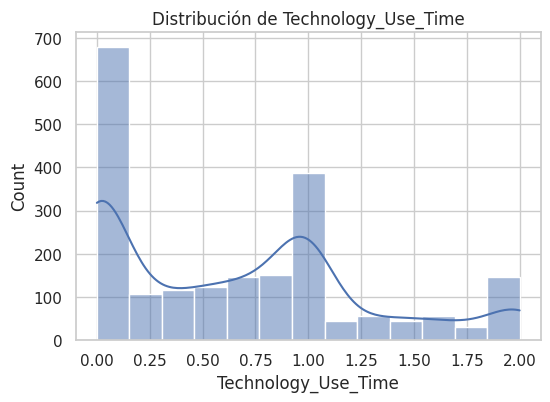

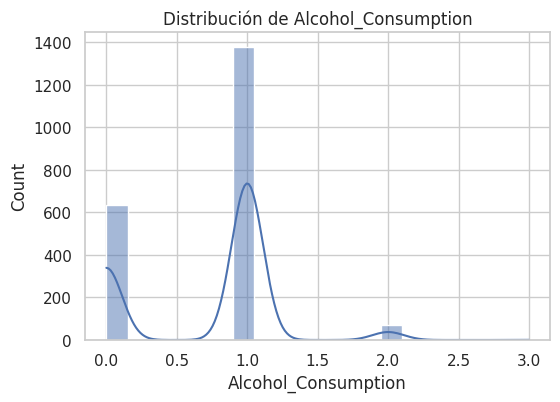

In [31]:
#VISUALIZACIONES
#Histograma y KDE
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

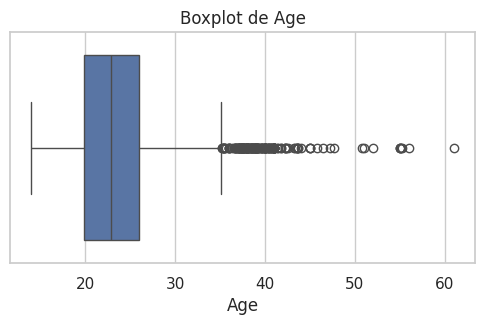

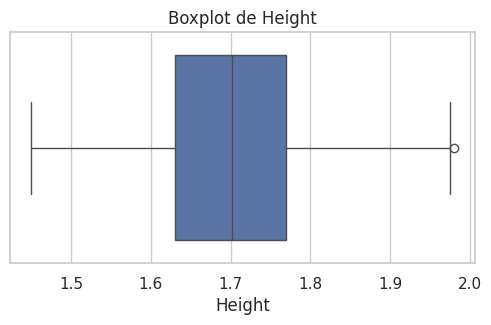

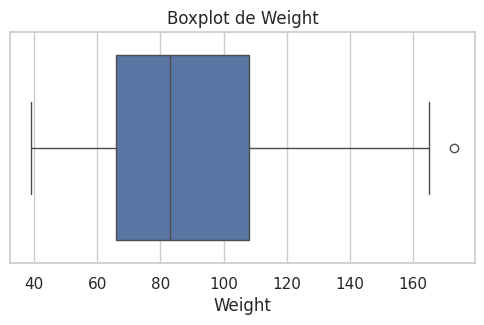

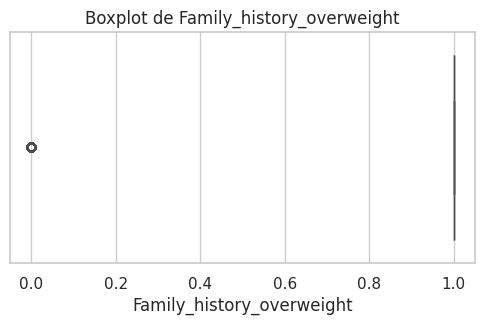

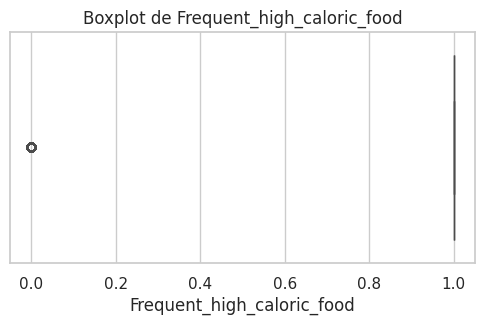

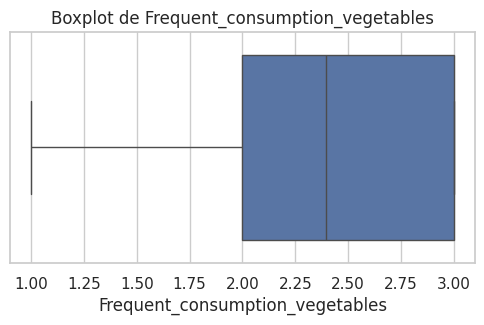

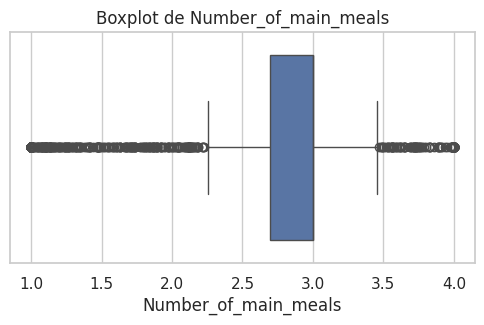

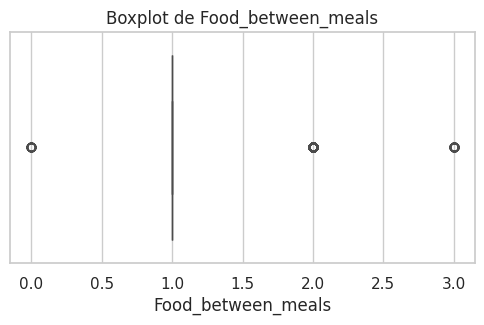

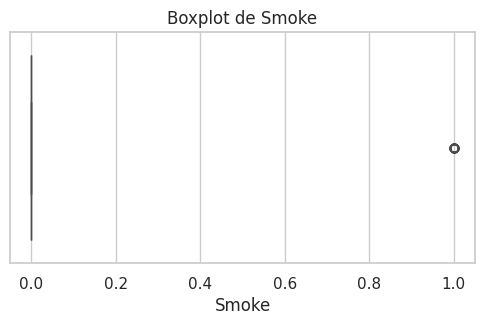

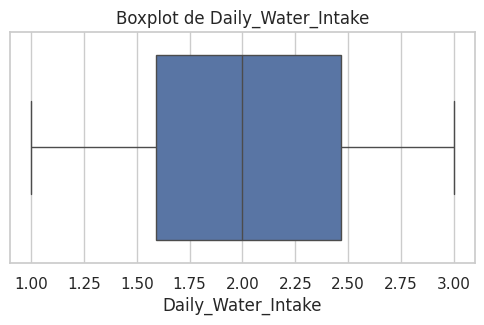

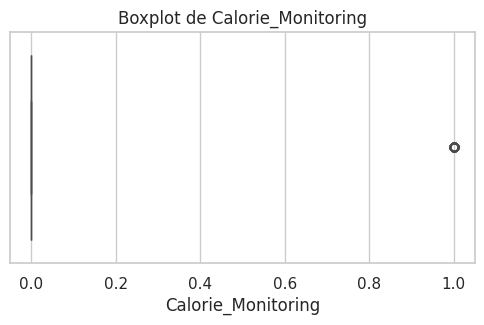

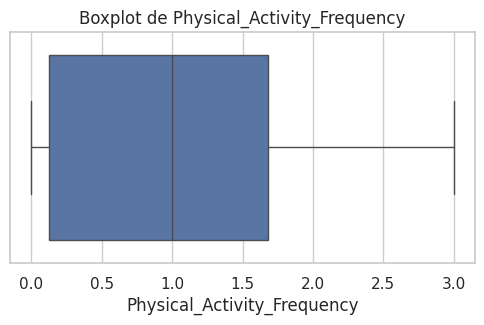

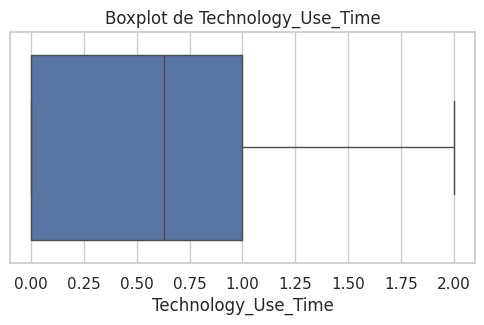

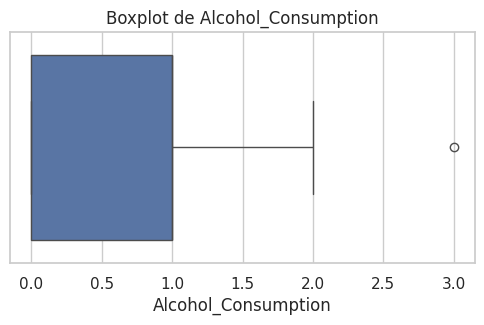

In [32]:
#Boxplots (outliers)
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

Analisis variables categoricas


In [48]:
#Numero de categorias
print("Número de categorías:", df[col].nunique())

Número de categorías: 7


In [39]:
#frecuecnias
df[col].value_counts()

,count
Obesity_Level,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_II,290
Normal_Weight,282
Overweight_Level_I,276
Insufficient_Weight,267


In [42]:
#Categorias dominantes
for col in cat_cols:
    print(f"\n Categoría dominante en {col}")
    print(df[col].value_counts().idxmax())


 Categoría dominante en Gender
Male

 Categoría dominante en Transportation_type
Public_Transportation

 Categoría dominante en Obesity_Level
Obesity_Type_I


In [43]:
#Categorías atipicas
for col in cat_cols:
    print(f"\n Categorías atipicas en {col}")
    print(df[col].value_counts()[df[col].value_counts() < 50])


 Categorías atipicas en Gender
Series([], Name: count, dtype: int64)

 Categorías atipicas en Transportation_type
Transportation_type
Motorbike    11
Bike          7
Name: count, dtype: int64

 Categorías atipicas en Obesity_Level
Series([], Name: count, dtype: int64)


In [49]:
for col in cat_cols:
    print(f"\n Valores únicos en {col}")
    print(df[col].unique())


 Valores únicos en Gender
['Female' 'Male']

 Valores únicos en Transportation_type
['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']

 Valores únicos en Obesity_Level
['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


In [36]:
#Analisis de frecuencias
for col in cat_cols:
    print(f"\n {col}")
    print(df[col].value_counts())


 Gender
Gender
Male      1052
Female    1035
Name: count, dtype: int64

 Transportation_type
Transportation_type
Public_Transportation    1558
Automobile                456
Walking                    55
Motorbike                  11
Bike                        7
Name: count, dtype: int64

 Obesity_Level
Obesity_Level
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64


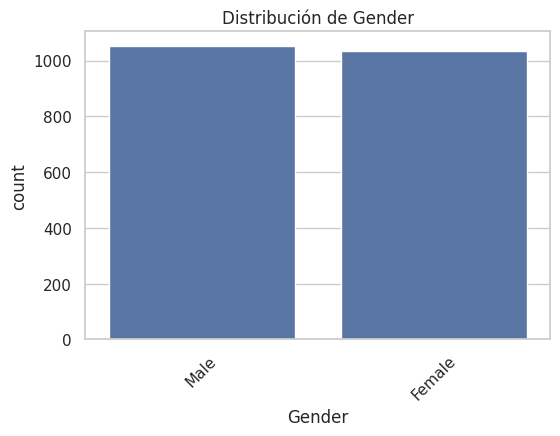

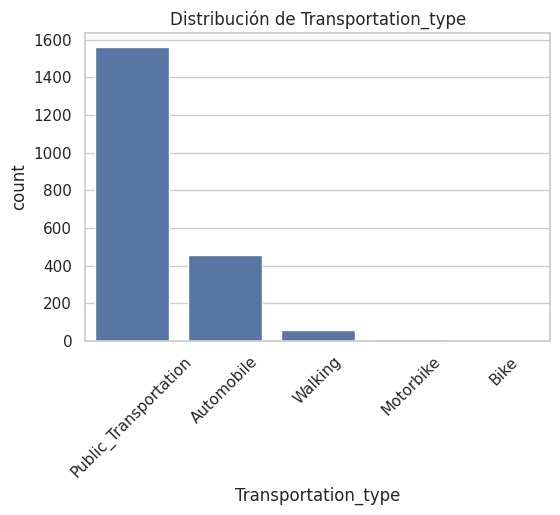

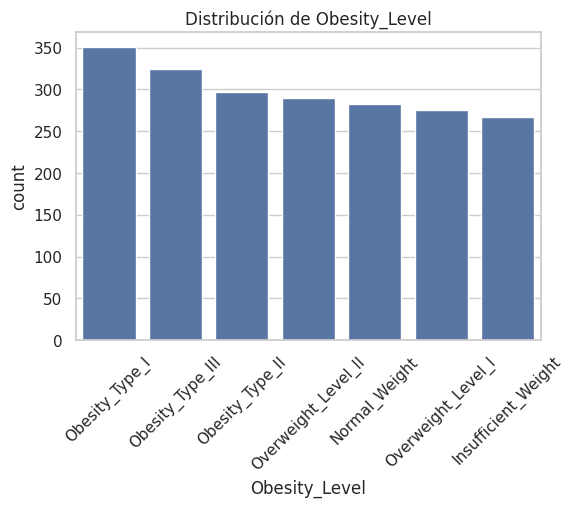

In [37]:
#Grafica de frecuencias
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"Distribución de {col}")
    plt.show()

FALTA LO DE Creamos features, analizamos
relaciones